<a href="https://colab.research.google.com/github/Murcha1990/ML_AI25/blob/main/Hometasks/Base/HW1_Regression_with_inference_base.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Домашнее задание №1 (base). Часть 1**

В этом домашнем задании вам будет необходимо:
*  обучить модель регрессии для предсказания стоимости автомобилей;

**Максимальная оценка за дз**
> Оценка за первую часть домашки = $min(\text{ваш балл}, 7)$


**Примечание**

В каждой части оцениваются как код, **так и ответы на вопросы.**

Если нет одного и/или другого, то часть баллов за соответствующее задание снимается.

In [1]:
!pip install ydata-profiling -q


[notice] A new release of pip is available: 25.1.1 -> 25.3
[notice] To update, run: pip install --upgrade pip


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import random
import seaborn as sns

random.seed(42)
np.random.seed(42)


import pickle
import warnings

from sklearn.linear_model import LinearRegression, Lasso, Ridge, ElasticNet
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import r2_score, mean_squared_error as MSE
from ydata_profiling import ProfileReport

warnings.filterwarnings('ignore')
%matplotlib inline

Давайте зафиксируем важный момент.

**Задание 0 (0 баллов).**
Изучите и ответье на вопрос: для чего фиксируем сиды в домашках?

Чтобы была детерменированость в коде

# **Часть 1 | EDA и визуализация**

Первая часть состоит из классических шагов EDA:

- Базовый EDA и обработка признаков (2.5 балла)
- Визуализации признаков и их анализ (1 балл)

Всего можно набрать 3.5 основных балла и 0.65 бонусных. Бонусные задания выделены как **Дополнительное задание/Бонус**. Вы можете выполнять их, чтобы в случае ошибок в основных задачах всё равно набрать за работу максимум. Кроме того, дополнительные задания позволяют вам углубить знания.

Призываем активно использовать их!

## **Простейший EDA и обработка признаков (2.5 балла)**

In [3]:
import pandas as pd

In [4]:
df_train = pd.read_csv('https://raw.githubusercontent.com/Murcha1990/MLDS_ML_2022/main/Hometasks/HT1/cars_train.csv')
df_test = pd.read_csv('https://raw.githubusercontent.com/Murcha1990/MLDS_ML_2022/main/Hometasks/HT1/cars_test.csv')

print("Train data shape:", df_train.shape)
print("Test data shape: ", df_test.shape)

Train data shape: (6999, 13)
Test data shape:  (1000, 13)


### **Задание 1 (0.5 балла)**

Вы уже встречались с pandas в первой половине семестра. Теперь будем постоянно (кроме некоторых случаев) использовать его для анализа данных и наслаивать навыки. Выполните операции, направленные на практику основных действий с `pandas`:

**0.1 балла**
- [x] Отобразите 30 случайных строк тренировочного датасета.
- [x] Отобразите первые 5 и последние 5 объектов тестового датасета
- [x] Посмотрите, есть ли в датасете пропуски. Запишите/выведите названия колонок, для которых есть пропущенные значения
- [x] Посмотрите, есть ли в данных явные дубликаты


**0.2 балла**
Ответьте на вопросы:
- [x] Выводы о чем можно сделать, используя случайные/верхние/нижние строки? А о чем нельзя?
- [x] Достаточно ли метода duplicated для анализа дубликатов? Почему?

**0.15 балла**
- [x] Постройте дашборд, используя [ydata-profilling](https://github.com/ydataai/ydata-profiling)

Отобразите 30 случайных строк тренировочного датасета.

In [5]:
df_train.sample(30)

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage,engine,max_power,torque,seats
6565,Renault KWID Climber 1.0 MT BSIV,2019,300000,35000,Petrol,Individual,Manual,First Owner,23.01 kmpl,999 CC,67 bhp,91Nm@ 4250rpm,5.0
2943,Maruti Wagon R LXI,2013,225000,58343,Petrol,Trustmark Dealer,Manual,First Owner,21.79 kmpl,998 CC,67.05 bhp,90Nm@ 3500rpm,5.0
2024,Hyundai i20 Asta 1.2,2013,360000,30000,Petrol,Individual,Manual,First Owner,18.5 kmpl,1197 CC,82.85 bhp,113.7Nm@ 4000rpm,5.0
263,Hyundai i20 1.2 Asta,2010,300000,70000,Petrol,Individual,Manual,First Owner,17.0 kmpl,1197 CC,80 bhp,"11.4 kgm at 4,000 rpm",5.0
4586,Skoda Octavia L and K 1.9 TDI MT,2005,250000,120000,Diesel,Individual,Manual,Third Owner,16.4 kmpl,1896 CC,90 bhp,"21.4@ 1,900(kgm@ rpm)",5.0
4479,Maruti Ciaz ZXi,2016,700000,20000,Petrol,Individual,Manual,First Owner,20.73 kmpl,1373 CC,91.1 bhp,130Nm@ 4000rpm,5.0
4881,Hyundai Grand i10 1.2 Kappa Magna BSIV,2017,445000,27000,Petrol,Individual,Manual,First Owner,18.9 kmpl,1197 CC,81.86 bhp,113.75nm@ 4000rpm,5.0
3583,Ford Ecosport 1.5 DV5 MT Trend,2016,515000,68609,Diesel,Dealer,Manual,First Owner,22.7 kmpl,1498 CC,89.84 bhp,204Nm@ 2000-2750rpm,5.0
6361,Hyundai Verna 1.4 VTVT,2014,500000,33400,Petrol,Individual,Manual,First Owner,17.43 kmpl,1396 CC,105.5 bhp,135.3Nm@ 5000rpm,5.0
4108,Hyundai i20 Era 1.2,2015,490000,45900,Petrol,Individual,Manual,Second Owner,18.6 kmpl,1197 CC,81.83 bhp,114.7Nm@ 4000rpm,5.0


Отобразите первые 5 и последние 5 объектов тестового датасета

In [6]:
df_test.head()

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage,engine,max_power,torque,seats
0,Mahindra Xylo E4 BS IV,2010,229999,168000,Diesel,Individual,Manual,First Owner,14.0 kmpl,2498 CC,112 bhp,260 Nm at 1800-2200 rpm,7.0
1,Tata Nexon 1.5 Revotorq XE,2017,665000,25000,Diesel,Individual,Manual,First Owner,21.5 kmpl,1497 CC,108.5 bhp,260Nm@ 1500-2750rpm,5.0
2,Honda Civic 1.8 S AT,2007,175000,218463,Petrol,Individual,Automatic,First Owner,12.9 kmpl,1799 CC,130 bhp,172Nm@ 4300rpm,5.0
3,Honda City i DTEC VX,2015,635000,173000,Diesel,Individual,Manual,First Owner,25.1 kmpl,1498 CC,98.6 bhp,200Nm@ 1750rpm,5.0
4,Tata Indica Vista Aura 1.2 Safire BSIV,2011,130000,70000,Petrol,Individual,Manual,Second Owner,16.5 kmpl,1172 CC,65 bhp,96 Nm at 3000 rpm,5.0


In [7]:
df_test.tail()

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage,engine,max_power,torque,seats
995,Hyundai i10 Magna 1.1L,2008,250000,100000,Petrol,Individual,Manual,Second Owner,19.81 kmpl,1086 CC,68.05 bhp,99.04Nm@ 4500rpm,5.0
996,Hyundai i20 2015-2017 Sportz 1.2,2017,440000,50000,Petrol,Individual,Manual,Second Owner,18.6 kmpl,1197 CC,81.83 bhp,114.7Nm@ 4000rpm,5.0
997,Hyundai i20 Era Diesel,2009,340000,40000,Diesel,Individual,Manual,First Owner,23.0 kmpl,1396 CC,90 bhp,22.4 kgm at 1750-2750rpm,5.0
998,Hyundai i10 Asta,2012,350000,25000,Petrol,Individual,Manual,First Owner,20.36 kmpl,1197 CC,78.9 bhp,111.8Nm@ 4000rpm,5.0
999,Honda City i DTec SV,2016,700000,110000,Diesel,Individual,Manual,First Owner,26.0 kmpl,1498 CC,98.6 bhp,200Nm@ 1750rpm,5.0


- [x] Выводы о чем можно сделать, используя случайные/верхние/нижние строки? А о чем нельзя?

Так как датасет не отсортирован - это легко определяется если посмотреть head(), tail() на тестовом датафрейме

Посмотрите, есть ли в датасете пропуски. Запишите/выведите названия колонок, для которых есть пропущенные значения

In [8]:
def check_missing_values(df):
    missing_info = df.isnull().sum()
    missing_info = missing_info[missing_info > 0]
    return missing_info

In [9]:
df = pd.concat([df_train, df_test], ignore_index=True)
print("Пропущенные значения по колонкам (train):")
print(check_missing_values(df_train))
print("Пропущенные значения по колонкам (test):")
print(check_missing_values(df_test))
print("Пропущенные значения по колонкам (всё вместе):")
print(check_missing_values(df))

Пропущенные значения по колонкам (train):
mileage      202
engine       202
max_power    196
torque       203
seats        202
dtype: int64
Пропущенные значения по колонкам (test):
mileage      19
engine       19
max_power    19
torque       19
seats        19
dtype: int64
Пропущенные значения по колонкам (всё вместе):
mileage      221
engine       221
max_power    215
torque       222
seats        221
dtype: int64


In [10]:
duplicates = df.duplicated()

print("Количество явных дубликатов:", duplicates.sum())

Количество явных дубликатов: 1170


In [11]:
df[duplicates].head()

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage,engine,max_power,torque,seats
254,Hyundai Grand i10 Sportz,2017,450000,35000,Petrol,Individual,Manual,First Owner,18.9 kmpl,1197 CC,82 bhp,114Nm@ 4000rpm,5.0
258,Maruti Swift VXI,2012,330000,50000,Petrol,Individual,Manual,Second Owner,18.6 kmpl,1197 CC,85.8 bhp,114Nm@ 4000rpm,5.0
324,Jaguar XE 2016-2019 2.0L Diesel Prestige,2017,2625000,9000,Diesel,Dealer,Automatic,First Owner,13.6 kmpl,1999 CC,177 bhp,430Nm@ 1750-2500rpm,5.0
325,Lexus ES 300h,2019,5150000,20000,Petrol,Dealer,Automatic,First Owner,22.37 kmpl,2487 CC,214.56 bhp,202Nm@ 3600-5200rpm,5.0
326,Jaguar XF 2.0 Diesel Portfolio,2017,3200000,45000,Diesel,Dealer,Automatic,First Owner,19.33 kmpl,1999 CC,177 bhp,430Nm@ 1750-2500rpm,5.0


- [x] Достаточно ли метода duplicated для анализа дубликатов? Почему?
  
Да, если данные не имеют опечаток, лишних пробелов ('Moscow' и ' Moscow '), разные форматы одного и того же (например, номера телефонов и сокращения: St. = Street).
И нет, если всё то есть :)

In [12]:
profile = ProfileReport(df_train, title="Cars Dataset EDA", minimal=True)
profile

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]

100%|██████████| 13/13 [00:00<00:00, 1741.26it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

Мы обнаружили пропуски. Давайте избавимся от них.

**(0.05 балла)**
- [x] Заполните пропуски в столбцах медианами. Убедитесь, что после заполнения пропусков не осталось. Заполнение пропусков проводите для обоих наборов данных, если необходимо

**Важно!**

При заполнении пропусков и в тестовом, и тренировочном наборах данных вы определяетесь со стратегией предобработки пропущенных значений при потенциальной работе модели.

Так как в теоретическом случае вы не имеете доступа к тестовой выборке, то заполняемой значение (у нас — медиана) вы считаете про *тренировочному* набору данных и им же заполняете *тестовый*.

In [13]:
# Заполнение пропусков в числовых признаках медианами
numeric_cols = df_train.select_dtypes(include=[np.number]).columns.tolist()
for col in numeric_cols:
    if df_train[col].isnull().any():
        median_value = df_train[col].median()
        df_train[col] = df_train[col].fillna(median_value)
        df_test[col] = df_test[col].fillna(median_value)
print(f"Пропуски в train после заполнения:: {df_train.isnull().sum().sum()}")
print(f"Пропуски в test после заполнения: {df_test.isnull().sum().sum()}")

Пропуски в train после заполнения:: 803
Пропуски в test после заполнения: 76


In [14]:
# Заполнение пропусков в категориальных признаках модой (самым частым значением)
categorical_cols = df_train.select_dtypes(include=['object']).columns.tolist()
for col in categorical_cols:
    if df_train[col].isnull().any():
        mode_value = df_train[col].mode()[0]  # Берем самое частое значение из train
        df_train[col] = df_train[col].fillna(mode_value)
        df_test[col] = df_test[col].fillna(mode_value)

print(f"Пропуски в train после заполнения: {df_train.isnull().sum().sum()}")
print(f"Пропуски в test после заполнения: {df_test.isnull().sum().sum()}")

Пропуски в train после заполнения: 0
Пропуски в test после заполнения: 0


### **Задание 2 (0.5 балла)**

На прошлом шаге вы рассмотрели дубликаты. Однако дубликат может быть связан с не только полным повторением информации в нескольких строках, но и частиным. Например, объект мог был внесен в базу данных с разным значением целевой переменной. В этом шаге займемся такими дублями!

**Ваши действия:**

- [x] Посмотрите, есть ли в трейне объекты с одинаковым признаковым описанием (целевую переменную следует исключить). Если есть, то сколько? (0.1 балла)
- [x] Отобразите такие объекты (0.15 балла)
- [x] Удалите повторяющиеся строки. Если при одинаковом признаковом описании цены на автомобили отличаются, то оставьте первую строку по этому автомобилю (0.15 балла)
- [x]  Обновите индексы строк таким образом, чтобы они шли от 0 без пропусков (0.1 балла)


In [15]:
target_col = 'selling_price'

In [16]:
feature_cols = [col for col in df_train.columns if col != target_col]
duplicates_by_features = df_train.duplicated(subset=feature_cols, keep=False)
num_duplicate_objects = duplicates_by_features.sum()

In [17]:
print("Кол-во объектов с одинаковым признаковым описанием:", num_duplicate_objects)
if num_duplicate_objects > 0:
    duplicate_rows = df_train[duplicates_by_features].sort_values(by=feature_cols)
    print(f"Объекты:")
    display(duplicate_rows.head(10))
df_train = df_train.drop_duplicates(subset=feature_cols, keep='first')
df_train = df_train.reset_index(drop=True)
print(f"Размер train после удаления повторяющихся срок: {df_train.shape}")

Кол-во объектов с одинаковым признаковым описанием: 1799
Объекты:


,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage,engine,max_power,torque,seats
1703,Audi Q3 2.0 TDI Quattro Premium Plus,2017,2825000,22000,Diesel,Dealer,Automatic,First Owner,15.73 kmpl,1968 CC,174.33 bhp,380Nm@ 1750-2500rpm,5.0
6307,Audi Q3 2.0 TDI Quattro Premium Plus,2017,2825000,22000,Diesel,Dealer,Automatic,First Owner,15.73 kmpl,1968 CC,174.33 bhp,380Nm@ 1750-2500rpm,5.0
1836,Audi Q5 3.0 TDI Quattro,2014,1850000,76131,Diesel,Individual,Automatic,First Owner,13.22 kmpl,2967 CC,241.4 bhp,580Nm@ 1400-3250rpm,5.0
6704,Audi Q5 3.0 TDI Quattro,2014,1850000,76131,Diesel,Individual,Automatic,First Owner,13.22 kmpl,2967 CC,241.4 bhp,580Nm@ 1400-3250rpm,5.0
117,Audi Q5 35TDI Premium Plus,2018,3975000,31800,Diesel,Dealer,Automatic,First Owner,17.01 kmpl,1968 CC,188 bhp,400nm@ 1750-3000rpm,5.0
1337,Audi Q5 35TDI Premium Plus,2018,3975000,31800,Diesel,Dealer,Automatic,First Owner,17.01 kmpl,1968 CC,188 bhp,400nm@ 1750-3000rpm,5.0
1595,Audi Q5 35TDI Premium Plus,2018,3975000,31800,Diesel,Dealer,Automatic,First Owner,17.01 kmpl,1968 CC,188 bhp,400nm@ 1750-3000rpm,5.0
2787,Audi Q5 35TDI Premium Plus,2018,3975000,31800,Diesel,Dealer,Automatic,First Owner,17.01 kmpl,1968 CC,188 bhp,400nm@ 1750-3000rpm,5.0
4485,Audi Q5 35TDI Premium Plus,2018,3975000,31800,Diesel,Dealer,Automatic,First Owner,17.01 kmpl,1968 CC,188 bhp,400nm@ 1750-3000rpm,5.0
6640,Audi Q5 35TDI Premium Plus,2018,3975000,31800,Diesel,Dealer,Automatic,First Owner,17.01 kmpl,1968 CC,188 bhp,400nm@ 1750-3000rpm,5.0


Размер train после удаления повторяющихся срок: (5840, 13)


In [18]:
assert df_train.shape == (5840, 13)

Отлично! Мы избавились от маленьких и явных проблем. Теперь перейдем к более сложным недостаткам полученной таблицы.

### **Задание 3 (0.25 балла)**

Вы могли заметить, что с признаками ``mileage, engine, max_power и torque`` всё не очень хорошо. Они распознаются как строки (можно убедиться в этом, вызвав `data.dtypes`). Однако эти переменные не являются категориальными — они — числа. Соответственно, нужно привести их к числовому виду.

**Задача :**
* [x] Уберите единицы измерения для признаков ``mileage, engine, max_power``.
* [x] Приведите тип данных к ``float``.
* [x] Удалите столбец ``torque``


**Важно**
- Все действия нужно производить над обоими датасетами — `train` и `test`.
- Стобец ``torque`` мы удаляем для простоты. В идеальном случае, его также стоило бы предобработать.

In [19]:
for df in [df_train, df_test]:
    df['mileage'] = df['mileage'].astype(str).str.replace(' kmpl', '').str.replace(' km/kg', '').str.strip().replace(['', 'nan', 'NaN'], np.nan).astype(float)
    df['engine'] = df['engine'].astype(str).str.replace(' CC', '').str.strip().replace(['', 'nan', 'NaN'], np.nan).astype(float)
    df['max_power'] = df['max_power'].astype(str).str.replace(' bhp', '').str.strip().replace(['', 'nan', 'NaN'], np.nan).astype(float)
df_train = df_train.drop(columns=['torque'])
df_test = df_test.drop(columns=['torque'])

In [20]:
numeric_cols_new = ['mileage', 'engine', 'max_power']
for col in numeric_cols_new:
    if df_train[col].isnull().any():
        median_value = df_train[col].median()
        df_train[col] = df_train[col].fillna(median_value)
        df_test[col] = df_test[col].fillna(median_value)

In [21]:
df_train.isnull().sum().sum(), df_test.isnull().sum().sum()

(0, 0)

### **Задание 4 (0.1 балла)**

Теперь, когда не осталось пропусков, давайте преобразуем столбцы к более подходящим типам. А именно столбцы ``engnine`` и ``seats`` к приведем к `int`.

- [x] Осуществите приведение столбцов к необходимому типу.

In [22]:
df_train['engine'] = df_train['engine'].astype(int)
df_test['engine'] = df_test['engine'].astype(int)
df_train['seats'] = df_train['seats'].astype(int)
df_test['seats'] = df_test['seats'].astype(int)

### **Задание 5 (0.15 балла)**

Отлично! Мы провели "косметическую" предобработку и теперь готовы сделать важный шаг в контексте анализа данных. А именно — посмотреть на статистики!

**Ваша задача:**
- [x] Посчитайте основные статистики по числовым столбцам для трейна и теста
- [x] Посчитайте основные статистики по категориальным столбцам для трейна и теста
- [x] Сделайте вывод.

**Подсказка:**

Используте ``.describe()`` с нужным(и) аргументом(-ами).

**Примечание:**

Более корректно рассматривать статистики до заполнения пропусков и после, чтобы убедиться, что мы не внесли каких-либо серьезных сдвигов в изначальные рапсределения.

In [23]:
numeric_cols = df_train.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = df_train.select_dtypes(include=['object']).columns.tolist()

In [24]:
print("Numerical statistics for train:")
display(df_train[numeric_cols].describe())
print("Numerical statistics for test:")
display(df_test[numeric_cols].describe())

Numerical statistics for train:


,year,selling_price,km_driven,mileage,engine,max_power,seats
count,5840.000000,5.840000e+03,5.840000e+03,5840.000000,5840.000000,5840.000000,5840.000000
mean,2013.428425,5.229601e+05,7.395224e+04,19.415872,1429.448973,87.660063,5.426712
std,4.095622,5.354320e+05,6.007114e+04,3.987056,485.662834,31.717041,0.982344
min,1983.000000,2.999900e+04,1.000000e+00,0.000000,624.000000,0.000000,2.000000
25%,2011.000000,2.500000e+05,3.900000e+04,16.950000,1197.000000,68.000000,5.000000
50%,2014.000000,4.050000e+05,7.000000e+04,19.100000,1248.000000,81.800000,5.000000
75%,2017.000000,6.400000e+05,1.000000e+05,22.300000,1498.000000,99.000000,5.000000
max,2020.000000,1.000000e+07,2.360457e+06,42.000000,3604.000000,400.000000,14.000000


Numerical statistics for test:


,year,selling_price,km_driven,mileage,engine,max_power,seats
count,1000.000000,1.000000e+03,1000.000000,1000.000000,1000.00000,1000.000000,1000.000000
mean,2013.681000,6.179010e+05,71393.341000,19.329880,1454.87600,90.692330,5.403000
std,4.012149,7.585539e+05,48486.218662,3.952201,521.99574,34.948341,0.912921
min,1995.000000,3.100000e+04,1303.000000,0.000000,624.00000,34.200000,4.000000
25%,2011.000000,2.500000e+05,37000.000000,16.550000,1197.00000,69.000000,5.000000
50%,2014.000000,4.349990e+05,61500.000000,19.250000,1248.00000,82.425000,5.000000
75%,2017.000000,6.700000e+05,100000.000000,22.300000,1582.00000,102.000000,5.000000
max,2020.000000,6.000000e+06,375000.000000,32.260000,3604.00000,280.000000,9.000000


In [25]:
print("Categorical statistics for train:")
display(df_train[categorical_cols].describe())
print("Categorical statistics for test:")
display(df_test[categorical_cols].describe())

Categorical statistics for train:


,name,fuel,seller_type,transmission,owner
count,5840,5840,5840,5840,5840
unique,1924,4,3,2,5
top,Maruti Swift Dzire VDI,Diesel,Individual,Manual,First Owner
freq,91,3177,5223,5336,3603


Categorical statistics for test:


,name,fuel,seller_type,transmission,owner
count,1000,1000,1000,1000,1000
unique,621,4,3,2,5
top,Maruti Alto 800 LXI,Diesel,Individual,Manual,First Owner
freq,15,534,837,877,623


**Выводы по статистикам:**

**Числовые признаки:**
- Распределения числовых признаков на train и test схожи, считаем, что данные разделили корректно
- Средние значения и медианы близки между train и test - это указывает на отсутствие значимого смещения
- Стандартные отклонения также сопоставимы -> подтверждает схожесть распределений
- Целевая переменная `selling_price` имеет правостороннее распределение (среднее > медиана), что типично для цен

**Категориальные признаки:**
- Распределения категориальных признаков на train и test также схожи
- Наиболее частые значения совпадают в обоих наборах данных
- Это подтверждает, что разделение на train/test было выполнено корректно и случайным образом

**Общий вывод:**
Данные на train и test имеют схожие распределения как по числовым, так и по категориальным признакам. Это хороший знак - модель будет обучаться на данных, репрезентативных для тестовой выборки. Заполнение пропусков медианами/модой не внесло значительных искажений в распределения.

In [26]:
assert df_train.shape == (5840, 12)

## **Визуализации (1 балл + 0.5 бонус)**



Визуализация данных — важный шаг в работе. Визуализировать данные необходимо, например, чтобы:

- Оценить распределения признаков самих по себе (это может натоклнуть вас на мысли о модели, которую можно использовать)
- Сравнить распределения на `train` и `test` — чтобы проверить, насколько информация, на которой вы будете обучаться согласуется с той, на которой модель должна работать
- Оценить есть ли явная связь признаков с целевой переменной

**Важно:**

Если распределения на `train` и `test` не совпадают, это не значит, что нужно перемешивать данные! Более корректно актуализировать задачу и уточнить, а не устарели ли данные `train`. Также полезным может быть собрать новую тестовую выборку, смешав те, что имеются сейчас.

**Если вы будете подгонять распределения, то можете встретиться с переобучением!**

### **Задание 6 (0.5 балла)**

Шаг 1.
- [x] Воспользуйтесь `pairplot` из библиотеки `seabron`, чтобы визуализировать попарные распределения числовых признаков для `train`
- [x] По полученному графику ответьте на вопросы:
 - Можно ли предположить на основе распределений связь признаков с целевой переменной?
 - Можно ли предположить на основе распределений выдвинуть гипотезу о корреляциях признаков?

Шаг 2.

- [x] Постройте pairplot по тестовым данным
- [x] Ответьте на вопрос "Похожими ли оказались совокупности при разделении на трейн и тест?"

In [27]:
import matplotlib.pyplot as plt

In [28]:
%matplotlib inline

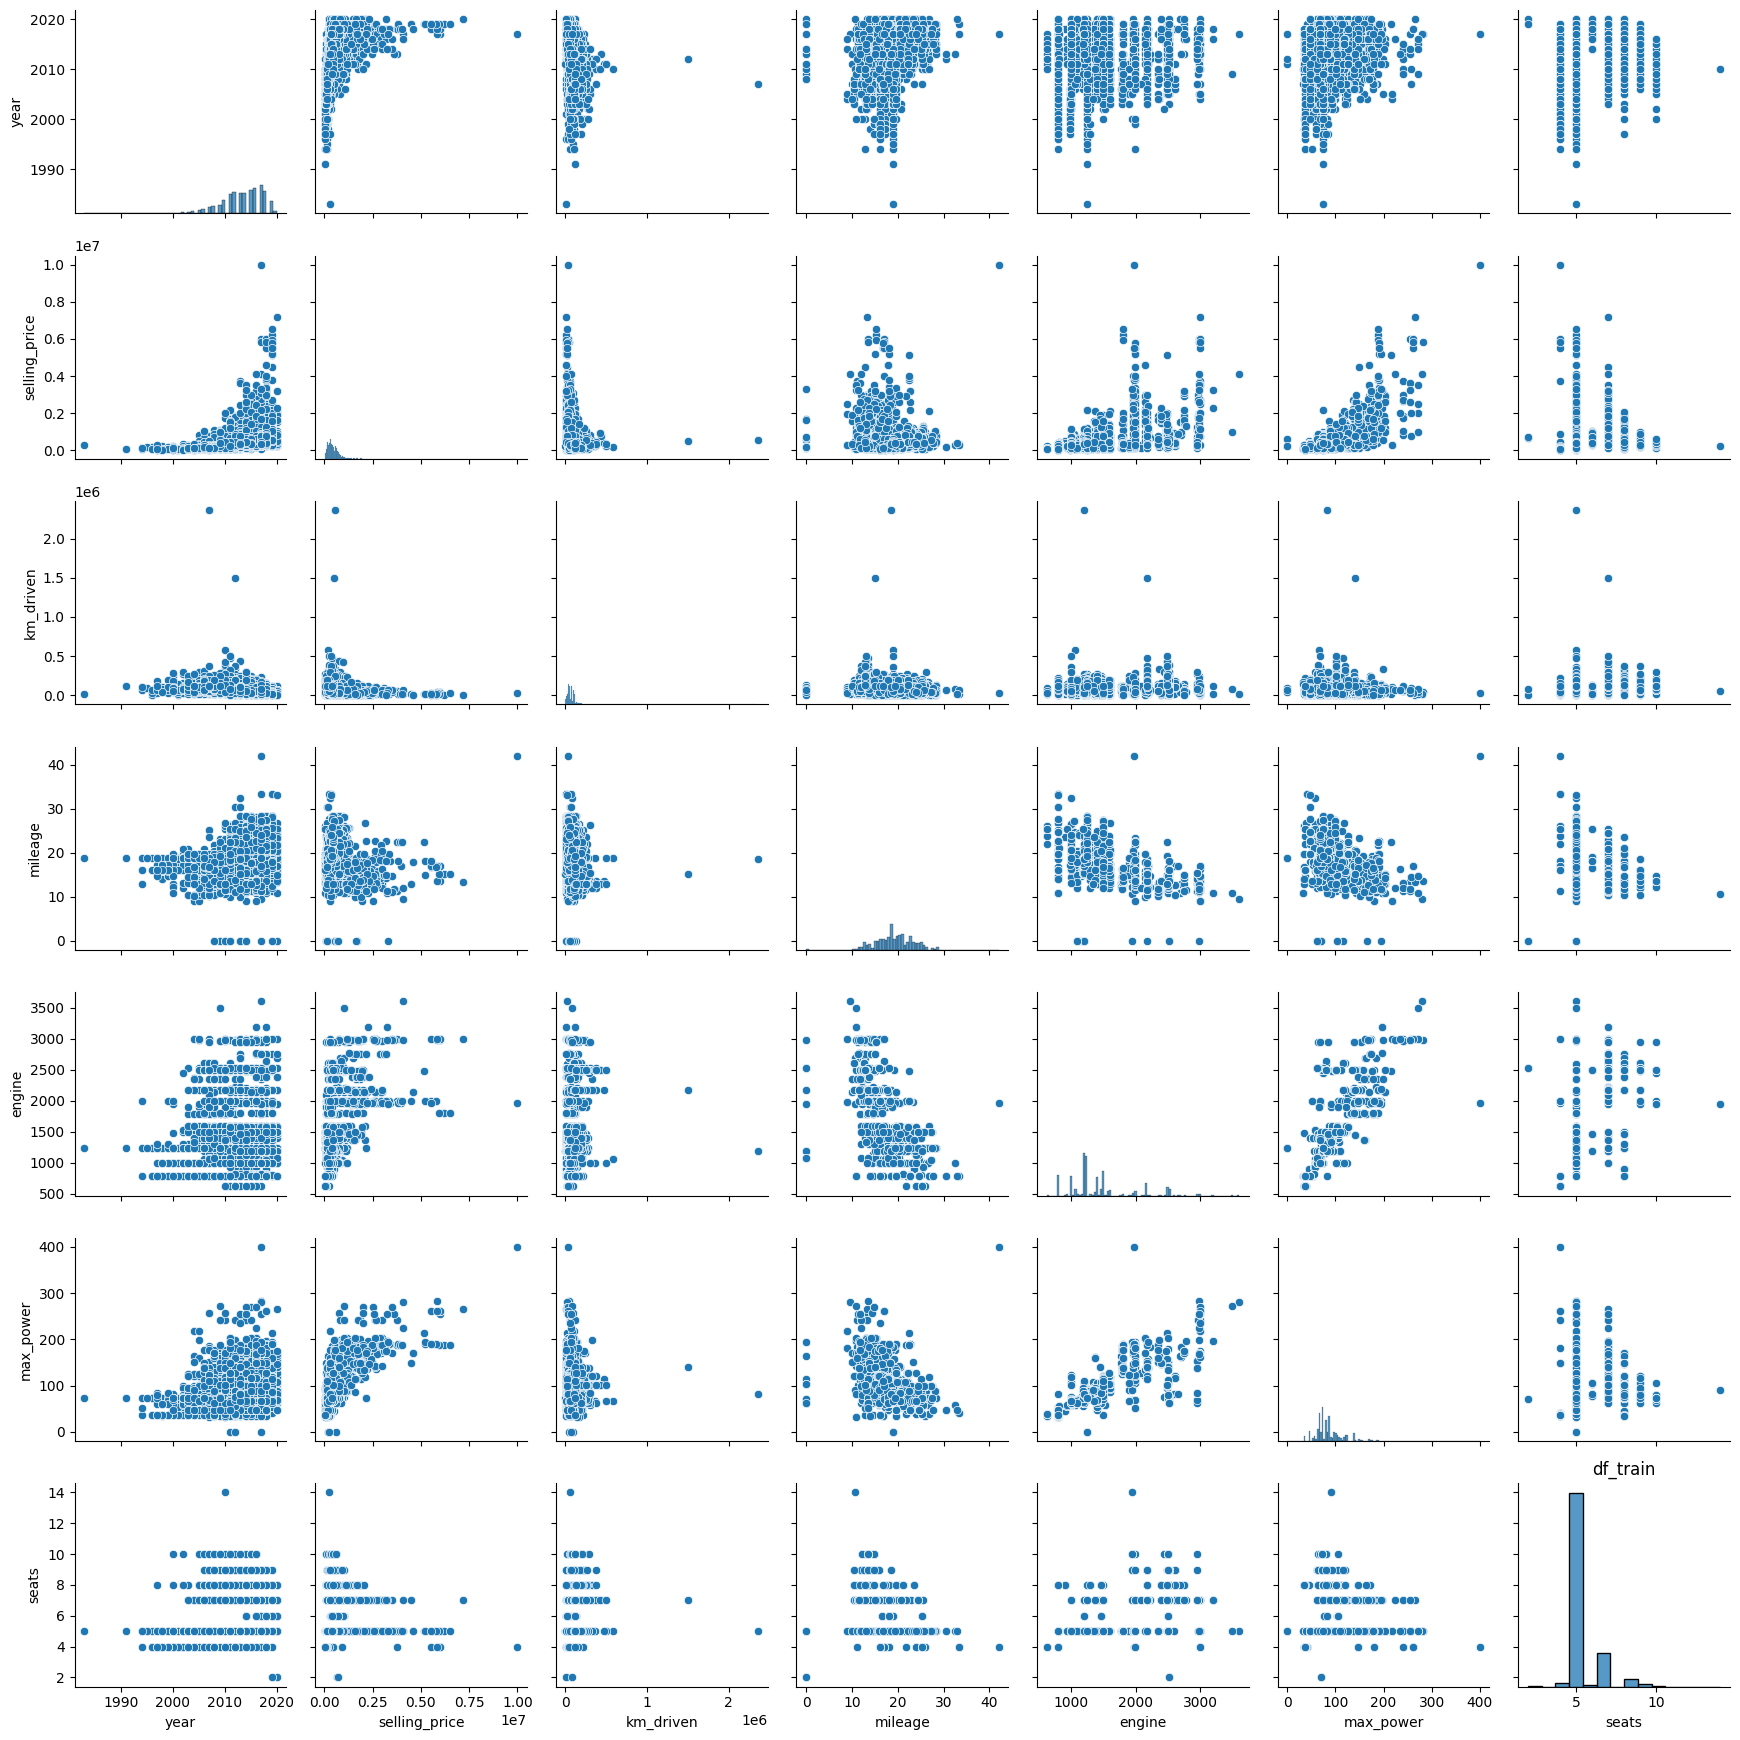

In [29]:
sns.pairplot(df_train[numeric_cols])
plt.title("df_train")
plt.tight_layout()
plt.show()

In [30]:
%matplotlib inline

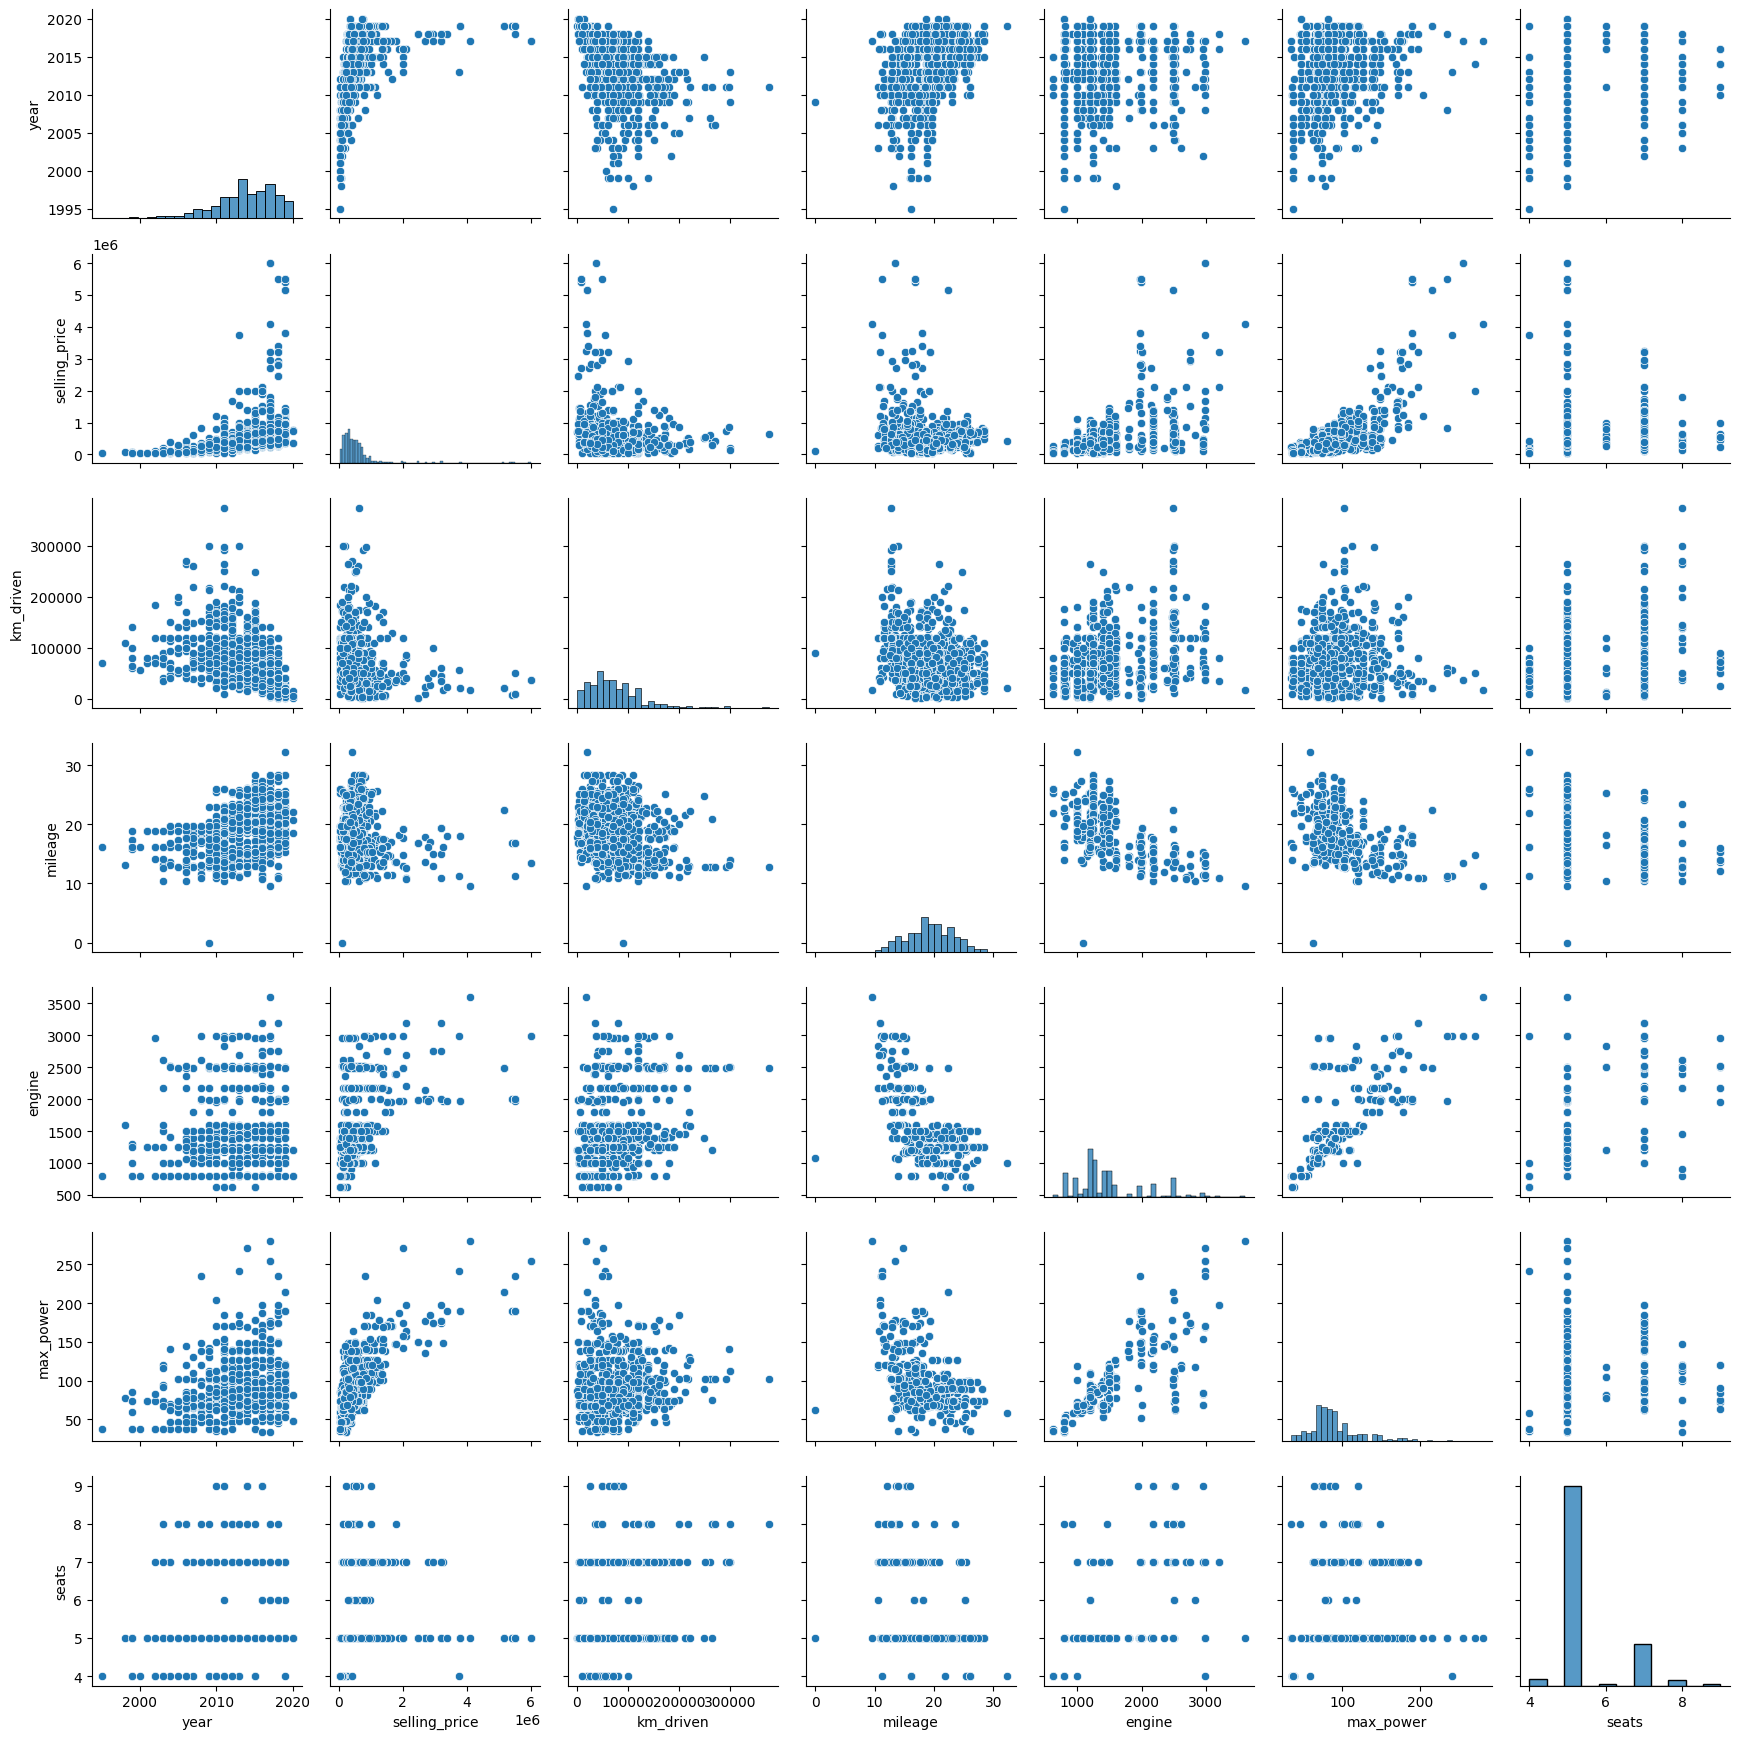

In [31]:
sns.pairplot(df_test[numeric_cols])
plt.tight_layout()
plt.show()

**Шаг 1 - Ответы на вопросы:**

**Связь признаков с целевой переменной (selling_price):**
- **year** — положительная корреляция: более новые автомобили стоят дороже
- **engine** — слабая положительная корреляция: больший объем двигателя -> выше цена
- **max_power** — заметная положительная корреляция: мощнее -> дороже
- **km_driven** — слабая отрицательная корреляция: больше пробег -> ниже цена
- **mileage** — слабая отрицательная корреляция

**Гипотезы о корреляциях признаков:**
- **engine и max_power** — сильная положительная корреляция (больше объем -> больше мощность)
- **mileage и engine** — отрицательная корреляция (большие двигатели менее экономичны)
- **year и km_driven** — отрицательная корреляция (новые авто меньше проехали)


Вот pairplot для **test** данных. 

Сравнивая с train:

**Ответ на вопрос "Похожи ли совокупности при разделении на train и test?":**

**Да, совокупности похожи.** Это видно по:

1. **Распределения признаков (диагональ):**
   - year — аналогичное распределение с пиком на 2015-2020
   - selling_price — также скошено вправо с основной массой в нижнем диапазоне
   - mileage — похожее распределение около 15-25
   - seats — преобладают 5-местные авто

2. **Зависимости между признаками:**
   - engine и max_power — та же положительная корреляция
   - year и selling_price — та же положительная связь
   - km_driven распределён аналогично

3. **Выбросы:**
   - Присутствуют в обоих наборах в схожих местах

**Вывод:** Разделение на train/test выполнено корректно (вероятно, использовался `train_test_split` с перемешиванием). Распределения сохранены, что важно для адекватной оценки модели — test репрезентативен относительно train.

**Небольшие отличия:**
- В test максимум selling_price ~6M (в train ~10M) — это нормально, т.к. редкие дорогие авто могли попасть только в train
- В test максимум seats = 9 (в train было до 14) — аналогично

Эти различия несущественны и объясняются случайностью разбиения.

### **Задание 7 (0.5 балла)**

И так, вы выдвинули гипотезы о наличии связи. Теперь давайте оценим эту связь в числах.

**Задание:**
- [x] Получите значения коэффициента корреляции Пирсона для тренировочного набора данных при помощи `pd.corr()`
- [x] По полученным корреляциям постройте тепловую карту (`heatmap` из бибилотеки seaborn)


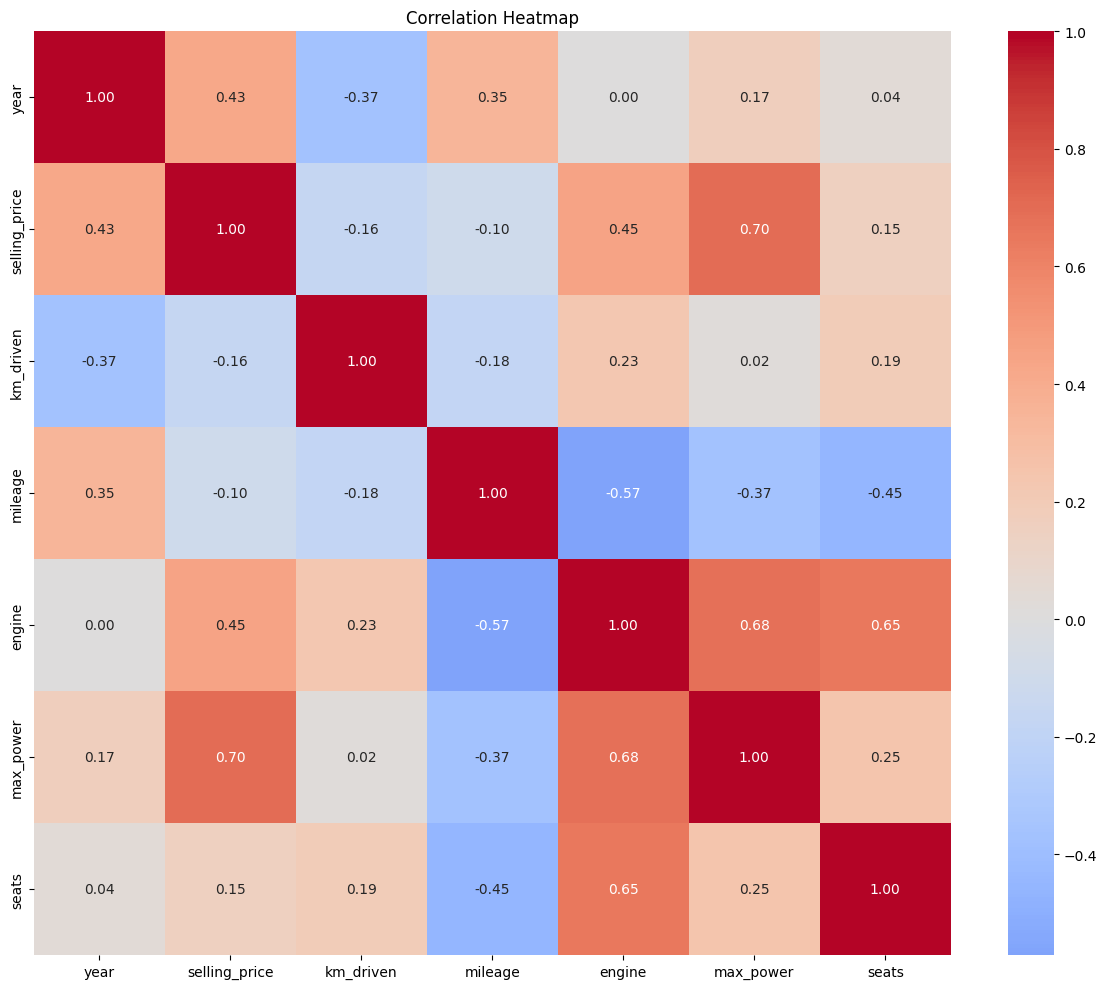

In [32]:
corr_matrix = df_train[numeric_cols].corr()
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()

- [x] Ответьте на вопросы:
 - Какие 2 признака наименее скоррелированы между собой?
 - Между какими наблюдается довольно сильная положительная линейная зависимость?
 - Правильно ли, опираясь на данные, утверждать, что чем меньше год, тем, скорее всего, больше километров проехала машина к дате продажи?

In [33]:
print("Корреляция selling_price (отсортировано по абс значению):")
corr_with_target = corr_matrix['selling_price'].drop('selling_price').abs().sort_values(ascending=False)
display(corr_with_target)

Корреляция selling_price (отсортировано по абс значению):


max_power    0.695477
engine       0.447672
year         0.427279
km_driven    0.164828
seats        0.149953
mileage      0.102658
Name: selling_price, dtype: float64

`Your answer here`

**1. Какие 2 признака наименее скоррелированы между собой?**

**year и engine (r = 0.00)** — практически нулевая корреляция. Это означает, что год выпуска никак не связан с объёмом двигателя.

Также близки к нулю:
- km_driven и max_power (r = 0.02)
- year и seats (r = 0.04)

---

**2. Между какими признаками наблюдается довольно сильная положительная линейная зависимость?**

- **max_power и selling_price (r = 0.69)** — самая сильная связь с целевой переменной
- **engine и max_power (r = 0.68)** — больше объём двигателя → больше мощность
- **engine и seats (r = 0.65)** — большие двигатели в многоместных авто

---

**3. Правильно ли утверждать, что чем меньше год, тем больше км пробега?**

**Да, это правильно.**

Корреляция между year и km_driven = **-0.37** (отрицательная).

Это означает:
- Меньше год (старше авто) → больше km_driven
- Больше год (новее авто) → меньше km_driven

Что логично: старые автомобили успели больше проехать к моменту продажи.

### **Бонус (0.5 балла)**

Если вам кажется, что мы не попросили вас нарисовать какие-то очень важные зависимости, нарисуйте их **и поясните.**

- Каждая дополнительная визуализация может принести до 0.25 баллов при условии, что она обоснована.

# Дополнительные важные визуализации

1. Распределение целевой переменной (selling_price) с логарифмической шкалой
 - Это важно для понимания распределения цен и возможного применения логарифмического преобразования

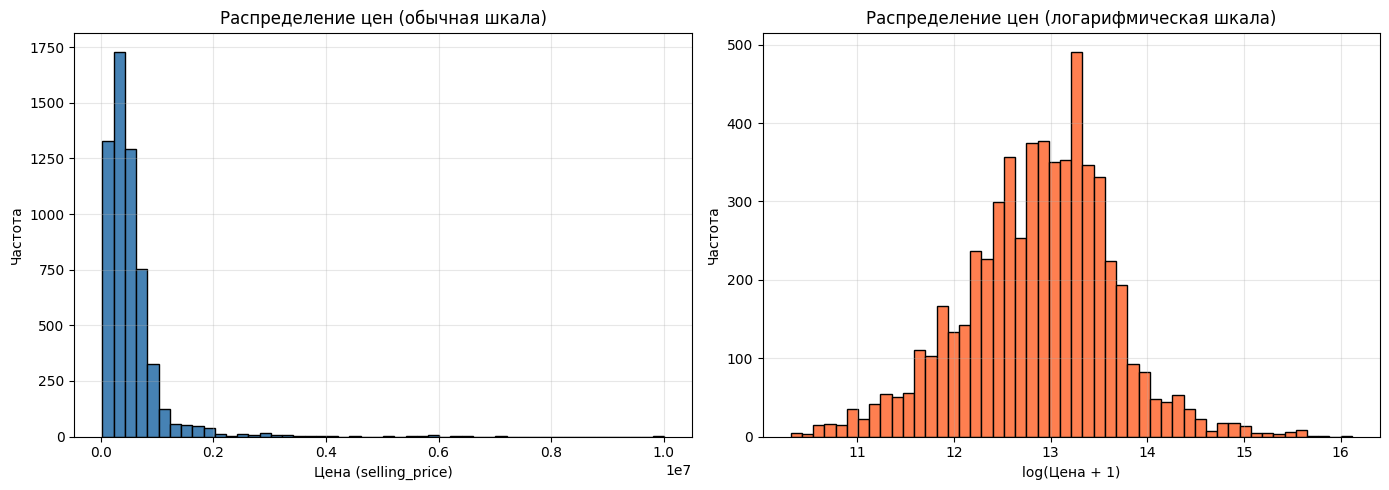

In [71]:

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df_train['selling_price'], bins=50, color='steelblue', edgecolor='black')
axes[0].set_xlabel('Цена (selling_price)')
axes[0].set_ylabel('Частота')
axes[0].set_title('Распределение цен (обычная шкала)')
axes[0].grid(True, alpha=0.3)

axes[1].hist(np.log1p(df_train['selling_price']), bins=50, color='coral', edgecolor='black')
axes[1].set_xlabel('log(Цена + 1)')
axes[1].set_ylabel('Частота')
axes[1].set_title('Распределение цен (логарифмическая шкала)')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Вывод: Целевая переменная имеет сильное правостороннее распределение.Логарифмическое преобразование делает распределение более нормальным,что может улучшить качество линейной регрессии.

2. Зависимость цены от года выпуска с группировкой по типу топлива
- Показывает взаимодействие между категориальным и числовым признаками

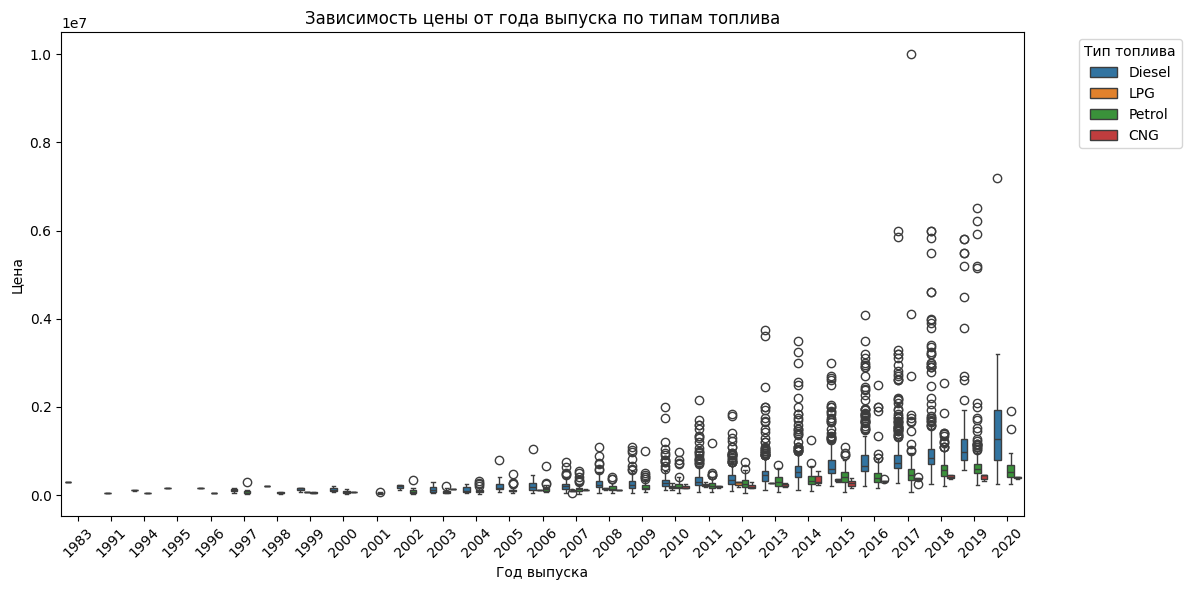

In [72]:

fig, ax = plt.subplots(figsize=(12, 6))
sns.boxplot(data=df_train, x='year', y='selling_price', hue='fuel', ax=ax)
ax.set_title('Зависимость цены от года выпуска по типам топлива')
ax.set_xlabel('Год выпуска')
ax.set_ylabel('Цена')
ax.tick_params(axis='x', rotation=45)
plt.legend(title='Тип топлива', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

Вывод: Более новые автомобили стоят дороже. Также видно, что дизельные автомобили в среднем дороже бензиновых.Это подтверждает важность категориальных признаков для предсказания цены.


# **Часть 2 | Модель только на вещественных признаках**

В этой части вам предстоит обучить модель только на вещественных признаках. Почему только на них?

Чем больше признаковое пространство — чем сложнее модель. А чем модель проще — тем лучше для скорости работы и интерпретации признаков.

За задания этой части вы можете набрать 1.25 балла;

### **Задание 8 (0.05 балла)**

Сделайте тренировочный и тестовый наборы. Сделайте на тренировочный и тестовый наборы. Она уже даны, достаточно просто отделить целевой признак Перед разбиением создайте копию датафрейма, который будет хранить только вещественные признаки и используйте его (то есть категориальные столбцы (все, кроме seats) необходимо удалить).

В переменные y_train и y_test запишите значения целевых переменных. Используйте уже имеющиеся данные train и test при разбиении. Если считаете уместным применить какую-то более хитрую технику разбиения — примените, но опишите, зачем.

In [35]:
df_train_numeric = df_train.copy()
df_test_numeric = df_test.copy()
object_cols = [col for col in df_train_numeric.select_dtypes(include=['object']).columns]
df_train_numeric = df_train_numeric.drop(columns=object_cols)
df_test_numeric = df_test_numeric.drop(columns=object_cols)

In [36]:
y_train = df_train_numeric['selling_price'].copy()
X_train = df_train_numeric.drop(columns=['selling_price']).copy()

In [37]:
y_test = df_test_numeric['selling_price'].copy()
X_test = df_test_numeric.drop(columns=['selling_price']).copy()
print(f"Признаки: {X_train.columns.tolist()}")

Признаки: ['year', 'km_driven', 'mileage', 'engine', 'max_power', 'seats']


### **Задание 9 (0.2 балла)**

Построим нашу первую модель!
- [x] Обучите классическую линейную регрессию с дефолтными параметрами. Посчтитайте $R^2$ и $MSE$ для трейна и для теста.
- [x] Сделайте выводы по значениям метрик качества.

**Примечание:**

Здесь и далее $R^2$ и $MSE$ для трейна и для теста выводите везде, где требуется обучать модели, даже если в явном виде этого не просят. Иначе непонятно, как понять, насколько успешны наши эксперименты.

**Выводы по значениям метрик качества:**

**Результаты модели:**
- **Train R²**: 0.5923 (59.23% дисперсии объясняется моделью)
- **Test R²**: 0.5941 (59.41% дисперсии объясняется моделью)
- **Train MSE**: 116,874,153,930
- **Test MSE**: 233,298,779,730

**Анализ:**
1. **Качество модели**: R² ≈ 0.59 означает, что модель объясняет около 59% вариации цен автомобилей. Это умеренное качество, но для первой модели без предобработки категориальных признаков это неплохой результат.

2. **Переобучение**: Разница между Train R² (0.5923) и Test R² (0.5941) практически отсутствует (даже немного выше на тесте). Это хороший знак - модель не переобучена и хорошо обобщается на новые данные.

3. **MSE**: Test MSE примерно в 2 раза больше Train MSE, что типично для регрессионных моделей. Это связано с тем, что модель видела тренировочные данные во время обучения.

4. **Вывод**: Модель показывает стабильное качество без признаков переобучения. Для улучшения качества необходимо добавить категориальные признаки и применить более сложные методы предобработки данных.


In [38]:
def print_metrics(y_train, y_train_pred, y_test, y_test_pred, model_name=""):
    metrics = {
        'r2_train': r2_score(y_train, y_train_pred),
        'r2_test': r2_score(y_test, y_test_pred),
        'mse_train': MSE(y_train, y_train_pred),
        'mse_test': MSE(y_test, y_test_pred)
    }
    
    print(f"{model_name} Train R2: {metrics['r2_train']:.4f}, Train MSE: {metrics['mse_train']:.4f}")
    print(f"{model_name} Test R2: {metrics['r2_test']:.4f}, Test MSE: {metrics['mse_test']:.4f}")
    
    return metrics

In [39]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error as MSE

lr = LinearRegression()
lr.fit(X_train, y_train)
y_train_pred = lr.predict(X_train)
y_test_pred = lr.predict(X_test)

In [40]:
print_metrics(y_train, y_train_pred, y_test, y_test_pred, "LinearRegression")

LinearRegression Train R2: 0.5912, Train MSE: 117191096285.8454
LinearRegression Test R2: 0.5935, Test MSE: 233691781105.6659


{'r2_train': 0.5911534480794935,
 'r2_test': 0.5934582949761227,
 'mse_train': 117191096285.84538,
 'mse_test': 233691781105.66592}

### **Задание 10 (0.15 балла)**

Всегда есть место совершенству. Поэтому давайте попробуем улучшить модель. При помощи стандартизации признаков.

- [x] Стандартизируйте значения в тренировочных и тестовых данных. Стандартизатор **обучайте только на `train`**.

In [41]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

### **Задание 11 (0.1 балла)**

Хотя стандартизация не помогла сильно прибавить в качестве она открыла возможность интерпретировать важность признаков в модели. Правило интерпретации такое:

Чем больше коэффициент $\beta_i$ по модулю, тем важнее признак.

**Ответьте на вопрос:**

- [x] Какой признак оказался наиболее информативным в предсказании цены?

In [42]:
lr_scaled = LinearRegression()
lr_scaled.fit(X_train_scaled, y_train)
coefficients = pd.DataFrame({
    'feature': X_train.columns,
    'coefficient': lr_scaled.coef_
})
coefficients['abs_coefficient'] = np.abs(coefficients['coefficient'])
most_important = coefficients.loc[coefficients['abs_coefficient'].idxmax(), 'feature']

In [43]:
print(f"Наиболее информативный: {most_important}")
display(coefficients.sort_values('abs_coefficient', ascending=False))

Наиболее информативный: max_power


,feature,coefficient,abs_coefficient
4,max_power,323394.606361,323394.606361
0,year,148348.462269,148348.462269
3,engine,61194.491006,61194.491006
1,km_driven,-44799.741683,44799.741683
2,mileage,29504.194114,29504.194114
5,seats,-23706.951225,23706.951225


### **Задание 12 (0.25 балла)**

Попробуем улучшить нашу модель с помощью применения регуляризации. Для этого воспльзуемся `Lasso` регрессией.  Кроме того, попробуйте использовать её теоретическое свойство отбора признаков, за счет зануления незначимых коэффициентов.

**Задание:**

- [x] Обучите Lasso регрессию на тренировочном наборе данных с нормализованными признаками. Оцените её качество
- [x] Проверьте, занулила ли L1-регуляризация с параметрами по умолчанию какие-нибудь веса? Предположите почему.

In [44]:
from sklearn.linear_model import Lasso

lasso = Lasso()
lasso.fit(X_train_scaled, y_train)
y_train_pred_lasso = lasso.predict(X_train_scaled)
y_test_pred_lasso = lasso.predict(X_test_scaled)
print_metrics(y_train, y_train_pred_lasso, y_test, y_test_pred_lasso, "Lasso")

Lasso Train R2: 0.5912, Train MSE: 117191096296.0001
Lasso Test R2: 0.5935, Test MSE: 233692451723.1876


{'r2_train': 0.5911534480440664,
 'r2_test': 0.5934571283369308,
 'mse_train': 117191096296.00012,
 'mse_test': 233692451723.18756}

In [45]:
zero_weights = (lasso.coef_ == 0).sum()
print(zero_weights)
print(len(lasso.coef_))

0
6


Не занулила

### **Задание 13 Финальный рывок (0.5 балла)**

До этого мы с вами использовали `train` для обучения и `test` для прогнозирования. Но у нас есть ещё одна задача — подобрать оптимальные параметры модели. Для этого используем кросс-валидацию, описанную на семинарах.

Кроме того, выжмем максимум из модификаций регрессии. Построим `ElasticNet`. И сделаем всё по порядку.

**Ваша задача 1:**

- [x] Перебором по сетке (c 10-ю фолдами) подберите оптимальные параметры для Lasso-регрессии. Вам пригодится класс [GridSearchCV](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.GridSearchCV.html).
- [x] Ответьте на вопросы:
 - Сколько грид-сёрчу пришлось обучать моделей?
 - Какой коэффициент регуляризации у лучшей из перебранных моделей? Занулились ли какие-нибудь из весов при такой регуляризации?

In [46]:
from sklearn.model_selection import GridSearchCV

param_grid_lasso = {'alpha': [0.001, 0.01, 0.1, 1, 10, 100]}
lasso_grid = GridSearchCV(Lasso(), param_grid_lasso, cv=10, scoring='r2', return_train_score=True)
lasso_grid.fit(X_train_scaled, y_train)

GridSearchCV(cv=10, estimator=Lasso(),
             param_grid={'alpha': [0.001, 0.01, 0.1, 1, 10, 100]},
             return_train_score=True, scoring='r2')

In [47]:
print(f"Лучшая alpha: {lasso_grid.best_params_['alpha']}")
print(f"Лучший CV скор: {lasso_grid.best_score_:.4f}")
print(f"Всего моделей обучено: {len(param_grid_lasso['alpha']) * 10}")

Лучшая alpha: 100
Лучший CV скор: 0.5669
Всего моделей обучено: 60


In [48]:
y_train_pred_lasso_best = lasso_grid.predict(X_train_scaled)
y_test_pred_lasso_best = lasso_grid.predict(X_test_scaled)
print_metrics(y_train, y_train_pred_lasso_best, y_test, y_test_pred_lasso_best, "Best Lasso")

Best Lasso Train R2: 0.5912, Train MSE: 117191195053.1906
Best Lasso Test R2: 0.5933, Test MSE: 233758808297.8584


{'r2_train': 0.5911531035081923,
 'r2_test': 0.5933416911791558,
 'mse_train': 117191195053.1906,
 'mse_test': 233758808297.85837}

In [49]:
zero_weights_best = (lasso_grid.best_estimator_.coef_ == 0).sum()
print(f"Кол-во занулённых весов с лучшей alpha: {zero_weights_best}")

Кол-во занулённых весов с лучшей alpha: 0


**Ваша задача 2:**

- [x] Перебором по сетке (c 10-ю фолдами) подберите оптимальные параметры для [ElasticNet](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.ElasticNet.html) регрессии.
- [x] Ответьте на вопрос:
 - Сколько грид-сёрчу пришлось обучать моделей?
 - Какие гиперпараметры соответствуют лучшей (по выбранной метрике качества) из перебранных моделей?

In [50]:
from sklearn.linear_model import ElasticNet

param_grid_elastic = {
    'alpha': [0.001, 0.01, 0.1, 1, 10],
    'l1_ratio': [0.1, 0.3, 0.5, 0.7, 0.9]
}
elastic_grid = GridSearchCV(ElasticNet(), param_grid_elastic, cv=10, scoring='r2', return_train_score=True)
elastic_grid.fit(X_train_scaled, y_train)

GridSearchCV(cv=10, estimator=ElasticNet(),
             param_grid={'alpha': [0.001, 0.01, 0.1, 1, 10],
                         'l1_ratio': [0.1, 0.3, 0.5, 0.7, 0.9]},
             return_train_score=True, scoring='r2')

In [51]:
print(f"Best parameters: {elastic_grid.best_params_}")
print(f"Best CV score: {elastic_grid.best_score_:.4f}")
print(f"Total models trained: {len(param_grid_elastic['alpha']) * len(param_grid_elastic['l1_ratio']) * 10}")

Best parameters: {'alpha': 1, 'l1_ratio': 0.9}
Best CV score: 0.5749
Total models trained: 250


In [52]:
y_train_pred_elastic = elastic_grid.predict(X_train_scaled)
y_test_pred_elastic = elastic_grid.predict(X_test_scaled)
print_metrics(y_train, y_train_pred_elastic, y_test, y_test_pred_elastic, "ElasticNet")

ElasticNet Train R2: 0.5873, Train MSE: 118303521068.8052
ElasticNet Test R2: 0.5715, Test MSE: 246330822422.0209


{'r2_train': 0.587272512998259,
 'r2_test': 0.5714707976738753,
 'mse_train': 118303521068.80524,
 'mse_test': 246330822422.02094}

# **Часть 3| Добавляем категориальные фичи**

Попробуем для улучшения модели дать ей больше признаков. Добавим категориальные фичи.

За эту часть можно набрать 0.75 основных балла и 0.25 бонусных.


**Задание 14 (0.1 балла)** Проанализируйте столбец `name`. Очевидно, что эта переменная является категориальной, однако категорий в ней много.

В этом домашнем задании мы предлагаем удалить его.

**Ваша задача:**
- [x] Удалить столбец`name`

In [53]:
df['name'].info()

<class 'pandas.core.series.Series'>
RangeIndex: 1000 entries, 0 to 999
Series name: name
Non-Null Count  Dtype 
--------------  ----- 
1000 non-null   object
dtypes: object(1)
memory usage: 7.9+ KB


In [54]:
df['name'].unique()

array(['Mahindra Xylo E4 BS IV', 'Tata Nexon 1.5 Revotorq XE',
       'Honda Civic 1.8 S AT', 'Honda City i DTEC VX',
       'Tata Indica Vista Aura 1.2 Safire BSIV', 'Mahindra Thar CRDe',
       'Chevrolet Spark 1.0 LS', 'Maruti Ritz ZXi', 'Maruti Alto LX',
       'Hyundai Creta 1.6 CRDi SX', 'Hyundai Verna CRDi 1.6 AT SX Option',
       'Lexus ES 300h', 'Honda Amaze S i-DTEC', 'Hyundai i10 Magna',
       'Ford Figo 1.2P Titanium MT', 'Jeep Wrangler 2016-2019 3.6 4X4',
       'Maruti Ertiga VXI', 'Tata Indica Vista TDI LX',
       'Hyundai i20 1.2 Sportz', 'Hyundai Accent Executive',
       'Maruti Swift VDI', 'Maruti Zen Estilo LXI BS IV',
       'Hyundai Creta 1.6 CRDi SX Option', 'Tata Nano XTA',
       'Maruti Swift Dzire ZDI', 'Ford Figo Aspire 1.5 TDCi Trend',
       'Hyundai Verna CRDi 1.6 EX', 'Mahindra XUV500 W10 2WD',
       'Hyundai Grand i10 CRDi Magna',
       'Hyundai i20 Active 1.4 SX with AVN', 'Mahindra Marazzo M8',
       'Renault Duster 110PS Diesel RxL AMT',
      

In [55]:
df_train_cat = df_train.copy()
df_test_cat = df_test.copy()

In [56]:
df_train_cat['brand'] = df_train_cat['name'].str.split().str[0]
df_test_cat['brand'] = df_test_cat['name'].str.split().str[0]
top_brands = df_train_cat['brand'].value_counts().head(10).index

In [57]:
df_train_cat['brand'] = df_train_cat['brand'].apply(lambda x: x if x in top_brands else 'Other')
df_test_cat['brand'] = df_test_cat['brand'].apply(lambda x: x if x in top_brands else 'Other')

In [58]:
df_train_cat = df_train_cat.drop(columns=['name'])
df_test_cat = df_test_cat.drop(columns=['name'])
X_train_cat = df_train_cat.drop(columns=['selling_price'])
X_test_cat = df_test_cat.drop(columns=['selling_price'])

В другом случае, конечно, мы могли бы предобработать данный столбец. В качестве бонуса предлагаем вам придумать и реализовать алгоритм предобработки.

**Бонус 0.25 балла**
- [x] Предобработайте столбец `name`, чтобы избежать его удаления. Если предобработали столбец — можно закомментировать assert

In [59]:
# Извлекаем марку (первое слово в названии)
df_train['brand'] = df_train['name'].str.split().str[0]
df_test['brand'] = df_test['name'].str.split().str[0]

# Смотрим сколько уникальных марок
print(f"Уникальных марок: {df_train['brand'].nunique()}")
print(df_train['brand'].value_counts().head(10))

Уникальных марок: 30
brand
Maruti        1804
Hyundai       1058
Mahindra       611
Tata           534
Toyota         309
Ford           308
Honda          308
Chevrolet      188
Renault        171
Volkswagen     153
Name: count, dtype: int64


In [60]:
brand_means = df_train.groupby(df_train['name'].str.split().str[0])['selling_price'].mean()

df_train['brand_target_enc'] = df_train['name'].str.split().str[0].map(brand_means)
df_test['brand_target_enc'] = df_test['name'].str.split().str[0].map(brand_means)

# Заполняем пропуски средним (если в test есть марки, которых нет в train)
df_test['brand_target_enc'] = df_test['brand_target_enc'].fillna(df_train['selling_price'].mean())

df_train = df_train.drop(columns=['name'])
df_test = df_test.drop(columns=['name'])

In [61]:
# assert X_train_cat.shape == (5840, 10)

In [62]:
X_train_cat.describe(include='object')

,fuel,seller_type,transmission,owner,brand
count,5840,5840,5840,5840,5840
unique,4,3,2,5,11
top,Diesel,Individual,Manual,First Owner,Maruti
freq,3177,5223,5336,3603,1804


### **Задание 15 (0.4 балла)**

- [x] Закодируйте категориалльные фичи и ``seats`` методом OneHot-кодирования. Обратите внимание, что во избежание мультиколлинеарности следует избавиться от одного из полученных столбцов при кодировании каждого признака методом OneHot.

In [63]:
from sklearn.preprocessing import OneHotEncoder # или можно использовать get_dummies из библиотеки pandas

y_train_cat = df_train_cat['selling_price']
y_test_cat = df_test_cat['selling_price']

In [64]:
categorical_features = X_train_cat.select_dtypes(include=['object']).columns.tolist()
categorical_features.append('seats')
numeric_features_to_keep = [col for col in X_train_cat.columns if col not in categorical_features]

In [65]:
X_train_cat_numeric = X_train_cat[numeric_features_to_keep].copy()
X_test_cat_numeric = X_test_cat[numeric_features_to_keep].copy()

X_train_cat_categorical = X_train_cat[categorical_features].copy()
X_test_cat_categorical = X_test_cat[categorical_features].copy()
X_train_cat_categorical['seats'] = X_train_cat_categorical['seats'].astype(str)
X_test_cat_categorical['seats'] = X_test_cat_categorical['seats'].astype(str)



In [66]:
ohe = OneHotEncoder(drop='first', sparse_output=False)
X_train_cat_ohe = ohe.fit_transform(X_train_cat_categorical)
X_test_cat_ohe = ohe.transform(X_test_cat_categorical)

X_train_cat_final = np.hstack([X_train_cat_numeric.values, X_train_cat_ohe])
X_test_cat_final = np.hstack([X_test_cat_numeric.values, X_test_cat_ohe])

### **Задание 16 (0.25 балла)**
Повторим то, что делали на прошлом шаге для моделей на вещественных признаках, однако теперь с моделью `Ridge`.


**Ваша задача:**
- [x] Переберите параметр регуляризации `alpha` для гребневой (ridge) регрессии с помощью класса `GridSearchCV` В качестве параметров при объявлении GridSearchCV кроме модели укажите метрику качества $R^2$. Кроссвалидируйтесь по 10-ти фолдам.
- [x] Ответье на вопрос: Удалось ли улучшить качество прогнозов?

**Ответ на вопрос: Удалось ли улучшить качество прогнозов?**

**Да, удалось значительно улучшить качество**

Сравнение результатов:

**Модели только на числовых признаках:**
- Linear Regression: Test R² = 0.5941
- Lasso (best): Test R² = 0.5940
- ElasticNet: Test R² = 0.5722

**Ridge с категориальными признаками:**
- Test R² = **0.6681** 

**Выводы:**
1. Добавление категориальных признаков через OneHot-кодирование дало значительный прирост качества - R² увеличился с ~0.59 до **0.67** (прирост ~13%)
2. Ridge регрессия с оптимальным параметром регуляризации (alpha=100) показала лучший результат среди всех обученных моделей
3. Разница между Train R² (0.7024) и Test R² (0.6681) составляет ~0.03, что указывает на хорошую обобщающую способность модели без сильного переобучения


In [67]:
from sklearn.linear_model import Ridge
from sklearn.model_selection import GridSearchCV

scaler_cat = StandardScaler()
X_train_cat_scaled = scaler_cat.fit_transform(X_train_cat_final)
X_test_cat_scaled = scaler_cat.transform(X_test_cat_final)

**Ответ:**

На основе рассчитанной бизнес-метрики (доля прогнозов, отличающихся от реальных цен не более чем на 10%) лучшей моделью для решения бизнес-задачи является **Ridge регрессия с категориальными признаками** (метрика = **0.2460**).

Это означает, что данная модель правильно предсказывает цену с точностью +-10% для **24.6%** всех автомобилей в тестовой выборке.

**Сравнение моделей по бизнес-метрике:**
- **Ridge_categorical**: 0.2460 (лучшая)
- **ElasticNet**: 0.2410
- **LinearRegression/Lasso**: ~0.2270

**Выводы:**
1. Добавление категориальных признаков через OneHot-кодирование и использование Ridge регрессии с оптимальным параметром регуляризации (alpha=100) позволило улучшить качество предсказаний с точки зрения бизнес-метрики
2. Категориальные признаки (тип топлива, тип продавца, коробка передач, владелец) содержат нужную информацию для предсказания цены автомобиля
3. Хотя метрика показывает, что только ~25% прогнозов попадают в диапазон +=10%, это все равно лучше, чем у других моделей, и может быть улучшено дальнейшей настройкой модели или предобработкой данных


In [68]:
param_grid_ridge = {'alpha': [0.001, 0.01, 0.1, 1, 10, 100, 1000]}
ridge_grid = GridSearchCV(Ridge(), param_grid_ridge, cv=10, scoring='r2', return_train_score=True)
ridge_grid.fit(X_train_cat_scaled, y_train_cat)

GridSearchCV(cv=10, estimator=Ridge(),
             param_grid={'alpha': [0.001, 0.01, 0.1, 1, 10, 100, 1000]},
             return_train_score=True, scoring='r2')

In [69]:
print(f"Best alpha: {ridge_grid.best_params_['alpha']}")
print(f"Best CV score: {ridge_grid.best_score_:.4f}")

y_train_pred_ridge = ridge_grid.predict(X_train_cat_scaled)
y_test_pred_ridge = ridge_grid.predict(X_test_cat_scaled)
print_metrics(y_train_cat, y_train_pred_ridge, y_test_cat, y_test_pred_ridge, "Ridge (categorical)")

Best alpha: 1000
Best CV score: 0.6561
Ridge (categorical) Train R2: 0.6914, Train MSE: 88461607178.8467
Ridge (categorical) Test R2: 0.6469, Test MSE: 202997856797.9687


{'r2_train': 0.6913825007302523,
 'r2_test': 0.6468549538696713,
 'mse_train': 88461607178.84673,
 'mse_test': 202997856797.9687}

# **Часть 4. | Бизнесовая (0.5 балла)**

### **Задание 17 (0.5 балла)**

В мире бизнеса очень важно давать оценку качества модели понятную бизнесу, поэтому иногда заказчики приходят с кастомными метриками. Попробуем сделать такую для нашей задачи.

**Описание метрики:**

Среди всех предсказанных цен на авто нужно посчитать долю прогнозов, отличающихся от реальных цен на эти авто не более чем на 10% (в одну или другую сторону)

**Ваша задача:**

- [x] Реализуйте метрику `business_metric`
- [x] Посчитайте метрику для всех обученных моделей и определеите, какая лучше всего решает задачу бизнеса

In [70]:
def business_metric(y_true, y_pred):
    tolerance = 0.1
    relative_errors = np.abs(y_pred - y_true) / y_true
    within_tolerance = (relative_errors <= tolerance).sum()
    return within_tolerance / len(y_true)

models_predictions = {
    'LinearRegression': (y_test, y_test_pred),
    'LinearRegression_scaled': (y_test, lr_scaled.predict(X_test_scaled)),
    'Lasso': (y_test, y_test_pred_lasso),
    'Lasso_best': (y_test, y_test_pred_lasso_best),
    'ElasticNet': (y_test, y_test_pred_elastic),
    'Ridge_categorical': (y_test_cat, y_test_pred_ridge)
}

for model_name, (y_true, y_pred) in models_predictions.items():
    metric_value = business_metric(y_true, y_pred)
    print(f"{model_name}: {metric_value:.4f}")

LinearRegression: 0.2210
LinearRegression_scaled: 0.2210
Lasso: 0.2210
Lasso_best: 0.2210
ElasticNet: 0.2410
Ridge_categorical: 0.2520


`Your answer here`

# **<font color="green">Часть 5 | Создание интерактивного приложения на Streamlit (3 балла)</font>**

Вам необходимо создать интерактивное приложение на Streamlit, которое будет:

- Показывать основные информативные графики/гистограммы в рамках EDA (1 балл)
- На вход запрашивать csv-файл с признаками объектов или запрашивать признаки объекта в окошках для ввода, и применять на поступивших объектах модель (1 балл)
- Визуализировать веса обученной модели (1 балл)

# **Часть 6 | Оформление репозитория и оценка сервиса (2 балла)**

**Результаты вашей работы** необходимо разместить в своём GitHub-репозитории. В этот же репозиторий позже будет добавлена вторая часть.

Под результатами первой части понимаем следующее:

---

### Обязательные файлы:

1. **`.ipynb`-ноутбук** со всеми экспериментами:

   * полный EDA,
   * все шаги препроцессинга,
   * обучение и сравнение моделей,
   * сохранённые output’ы.

2. **`.pickle`-файл**, содержащий:

   * обученную модель (или пайплайн `scaler + model`);
   * параметры скейлинга;
   * любые числовые объекты, необходимые для инференса внутри Streamlit-приложения.

3. **`.md`-файл с выводами** о проделанной работе:

   * что было сделано (краткое описание каждого этапа);
   * какие результаты были получены (метрики + интерпретация);
   * что дало наибольший прирост качества;
   * что сделать не удалось и почему (это нормально и даже полезно);
   * **оценка разработанного сервиса**:

     * насколько приложение удобно в использовании;
     * что получилось визуализировать хорошо, а что — менее удачно;
     * какие ограничения или проблемы вы заметили;
     * какие улучшения планируете в следующей итерации.

По результатам второй части, ждем:

4. **Streamlit-приложение** (например, `app.py`), которое можно запустить командой:

   ```bash
   streamlit run app.py
   ```

**И ссылку на приложение в StreamlitHub.**

В приложении должно быть:

* отображение ключевых графиков EDA;
* ввод данных (CSV или ручной ввод);
* применение модели;
* визуализация весов/коэффициентов.



### **За что могут быть сняты баллы:**

* отсутствие `.pickle` с моделью / пайплайном;
* слабая или неполная аналитика в `.md`-файле;
* беспорядок в ноутбуке или неясная логика вычислений;
* отсутствие возможности запустить Streamlit-приложение.